In [1]:
import kagglehub
import pandas as  pd  
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout

/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")
df = pd.read_csv(os.path.join(path, "diabetes.csv"))
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
df.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.495990
BloodPressure               0.174469
SkinThickness               0.295138
Insulin                     0.377081
BMI                         0.315577
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

In [4]:
x = df.iloc[:,0:-1].values
y = df.iloc[:,-1].values


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
x = scaler.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)

In [6]:

model = Sequential()
model.add(Dense(32, activation="relu", input_dim = 8))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=32, epochs = 100, validation_data=(x_test, y_test))

Epoch 1/100


/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1789985205.434020   56838 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5554 - loss: 0.7559 - val_accuracy: 0.6104 - val_loss: 0.6880
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6547 - loss: 0.6693 - val_accuracy: 0.6948 - val_loss: 0.6121
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6694 - loss: 0.6058 - val_accuracy: 0.7078 - val_loss: 0.5573
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7003 - loss: 0.5609 - val_accuracy: 0.7403 - val_loss: 0.5185
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7199 - loss: 0.5288 - val_accuracy: 0.7597 - val_loss: 0.4889
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7264 - loss: 0.5039 - val_accuracy: 0.7727 - val_loss: 0.4659
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7362 - loss: 0.4844 - val_accuracy: 0.7922 - val_loss: 0.4493
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7508 - loss: 0.4708 - val_accuracy: 0.8312 - val_loss: 0.4

<h3>But this architecture was purely based on the intution</h3>
But actually the question is how to select:
<ol>
<li>An appropiate optimizer
<li>Number of nodes in a layer
<li>Number of hidden layers
</ol>

In [7]:
import kerastuner as kt

/tmp/ipykernel_56838/1654478174.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


<h1>Selecting an appropiate Optimizer</h1>

We makea function which takes 'hp' and tunes it according to choice given

In [8]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(32, activation = "relu", input_dim = 8))
    model.add(Dense(1, activation="sigmoid"))

    optimizer = hp.Choice('optimizer', values =['adam', 'sgd', 'rmsprop', 'adadelta'])
    model.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])

    return model

We make a tuner object which is bacially a keras tuner object which have an 'objective'<br>
It does a random search as in it chooses different combinations of hyperparameters randomly to test<br>
Since we have given max_trails = 5 it will try 5 different combinations<br>
Now the directiry part is optional as it if we dont use it, it bydefault creates json files for each trail<br>
<br>
kerastuner.RandomSearch( HYPERMODEL, OBJECTIVE, MAX_TRIAL, SEED)

In [9]:
import tempfile
tuner = kt.RandomSearch(build_model, objective = 'val_accuracy',directory = tempfile.mkdtemp(), max_trials = 5)


This is the actual serach function which does the experiment

In [10]:
tuner.search(x_train, y_train, epochs = 5, validation_data = (x_test, y_test))

Trial 4 Complete [00h 00m 02s]
val_accuracy: 0.7922077775001526

Best val_accuracy So Far: 0.7922077775001526
Total elapsed time: 00h 00m 07s


In [11]:
#Thsi gives summary of each trial
tuner.results_summary()

Results summary
Results in /tmp/tmp1sqkk4l_/untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 3 summary
Hyperparameters:
optimizer: rmsprop
Score: 0.7922077775001526

Trial 0 summary
Hyperparameters:
optimizer: adam
Score: 0.7662337422370911

Trial 2 summary
Hyperparameters:
optimizer: sgd
Score: 0.6948052048683167

Trial 1 summary
Hyperparameters:
optimizer: adadelta
Score: 0.4350649416446686


In [12]:
#Gives the best hyperparameter
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'rmsprop'}

Now we can directly train the model using the best hyperparameter

In [13]:
model = tuner.get_best_models(num_models=1)[0]

/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(store)


In [14]:
model.fit(x_train, y_train, epochs = 100, initial_epoch = 6, validation_data=(x_test, y_test))

Epoch 7/100


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7638 - loss: 0.4829 - val_accuracy: 0.7987 - val_loss: 0.4621
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7687 - loss: 0.4636 - val_accuracy: 0.7987 - val_loss: 0.4469
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7720 - loss: 0.4519 - val_accuracy: 0.7987 - val_loss: 0.4353
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7752 - loss: 0.4433 - val_accuracy: 0.8052 - val_loss: 0.4262
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7818 - loss: 0.4363 - val_accuracy: 0.8117 - val_loss: 0.4204
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7866 - loss: 0.4306 - val_accuracy: 0.8052 - val_loss: 0.4139
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7932 - loss: 0.4258 - val_accuracy: 0.8117 - val_loss: 0.4085
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7997 - loss: 0.4214 - val_accuracy: 0.8117 - val_los

<h1>Selecting an appropiate number of nodes in a layer</h1>

In [15]:
def build_model(hp):
    model = Sequential()
    units = hp.Int('units', min_value = 8, max_value = 128, step = 8)

    model.add(Dense(units = units, activation = 'relu', input_dim = 8))
    model.add(Dense(1, activation = 'sigmoid'))
    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics=['accuracy'])

    return model

In [16]:
tuner = kt.RandomSearch(build_model, objective = 'val_accuracy',directory = tempfile.mkdtemp(), max_trials = 5)

/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
tuner.search(x_train, y_train, epochs = 5, validation_data = (x_test, y_test))

Trial 5 Complete [00h 00m 05s]
val_accuracy: 0.8181818127632141

Best val_accuracy So Far: 0.8311688303947449
Total elapsed time: 00h 00m 15s


In [18]:
tuner.get_best_hyperparameters()[0].values

{'units': 72}

In [19]:
model = tuner.get_best_models(num_models=1)[0]
model.fit(x_train, y_train, epochs = 100, initial_epoch = 6, validation_data=(x_test, y_test))

Epoch 7/100


/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(store)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7687 - loss: 0.4887 - val_accuracy: 0.8247 - val_loss: 0.4434
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7801 - loss: 0.4616 - val_accuracy: 0.8182 - val_loss: 0.4209
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7834 - loss: 0.4449 - val_accuracy: 0.8182 - val_loss: 0.4093
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7850 - loss: 0.4356 - val_accuracy: 0.8312 - val_loss: 0.4018
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7899 - loss: 0.4285 - val_accuracy: 0.8312 - val_loss: 0.3985
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7932 - loss: 0.4213 - val_accuracy: 0.8377 - val_loss: 0.3932
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7932 - loss: 0.4160 - val_accuracy: 0.8377 - val_loss: 0.3895
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8013 - loss: 0.4113 - val_accuracy: 0.8377 - val_lo

<h1>Selecting an appropiate number of layers</h1>

In [20]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(72, activation='relu', input_dim = 8))

    for i in range(hp.Int('num_layers', min_value = 1, max_value = 10)):
        model.add(Dense(72, activation='relu'))
    model.add(Dense(1, activation = "sigmoid"))
    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics=['accuracy'])

    return model

In [21]:
tuner = kt.RandomSearch(build_model, objective = 'val_accuracy', directory = tempfile.mkdtemp(), max_trials = 3)
tuner.search(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Trial 3 Complete [00h 00m 04s]
val_accuracy: 0.8311688303947449

Best val_accuracy So Far: 0.8571428656578064
Total elapsed time: 00h 00m 12s


In [22]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 1}

In [23]:
model = tuner.get_best_models(num_models = 1)[0]
model.fit(x_train, y_train, epochs = 100, initial_epoch=6, validation_data=(x_test, y_test))

Epoch 7/100


/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(store)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8127 - loss: 0.3860 - val_accuracy: 0.8636 - val_loss: 0.3585
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8306 - loss: 0.3712 - val_accuracy: 0.8571 - val_loss: 0.3505
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8502 - loss: 0.3569 - val_accuracy: 0.8701 - val_loss: 0.3449
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8550 - loss: 0.3466 - val_accuracy: 0.8766 - val_loss: 0.3381
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8664 - loss: 0.3389 - val_accuracy: 0.8701 - val_loss: 0.3348
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8664 - loss: 0.3298 - val_accuracy: 0.8701 - val_loss: 0.3302
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8730 - loss: 0.3236 - val_accuracy: 0.8636 - val_loss: 0.3339
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8746 - loss: 0.3157 - val_accuracy: 0.8571 - val_los

<h1>Using all of them all at once</h1>

In [54]:
def build_model(hp):
    model = Sequential()

    counter = 0
    for i in range(hp.Int('num_layers', min_value = 2, max_value = 4)):
        if counter ==0:
            model.add(Dense(
                hp.Int('units '+ str(i), min_value = 8, max_value = 64, step = 16),
                activation = hp.Choice('activation ' + str(i), values = ['relu', 'tanh', 'sigmoid']),
                input_dim = 8
            ))
        else:
            model.add(Dense(
                hp.Int('units '+ str(i), min_value = 8, max_value = 64, step =16),
                activation = hp.Choice('activation ' + str(i), values = ['relu', 'tanh', 'sigmoid']),
            ))
            model.add(Dropout(hp.Choice('droput '+ str(i), values = [0.8, 0.6, 0.4, 0.2])))
        counter += 1

    model.add(Dense(1, activation = 'sigmoid'))
    model.compile(
        optimizer = hp.Choice('optimizer', values = ['rmsprop', 'adam', 'sgd', 'nadam', 'adadelta']),
        loss='binary_crossentropy',
        metrics=['accuracy']
        )
    return model

In [55]:
tuner = kt.RandomSearch(
    build_model,
    objective = 'val_accuracy',
    max_trials = 50,
    directory = 'mydir'
    )

In [56]:
tuner.search(x_train, y_train, epochs = 3, validation_data = (x_test, y_test))

Trial 50 Complete [00h 00m 05s]
val_accuracy: 0.8051947951316833

Best val_accuracy So Far: 0.8246753215789795
Total elapsed time: 00h 03m 52s


In [57]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 2,
 'units 0': 56,
 'activation 0': 'relu',
 'units 1': 40,
 'activation 1': 'relu',
 'droput 1': 0.2,
 'optimizer': 'rmsprop',
 'units 2': 40,
 'activation 2': 'relu',
 'droput 2': 0.6,
 'units 3': 40,
 'activation 3': 'relu',
 'droput 3': 0.6}

In [59]:
model = tuner.get_best_models()[0]

/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(store)


In [61]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 56)             │           504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         2,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,825 (11.04 KB)

 Trainable params: 2,825 (11.04 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history = model.fit(x_train, y_train, epochs = 100, validation_data=(x_test, y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7883 - loss: 0.4315 - val_accuracy: 0.8247 - val_loss: 0.3972
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8094 - loss: 0.4128 - val_accuracy: 0.8247 - val_loss: 0.3874
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8192 - loss: 0.3987 - val_accuracy: 0.8377 - val_loss: 0.3802
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8176 - loss: 0.3920 - val_accuracy: 0.8442 - val_loss: 0.3733
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8208 - loss: 0.3865 - val_accuracy: 0.8506 - val_loss: 0.3692
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8208 - loss: 0.3851 - val_accuracy: 0.8571 - val_loss: 0.3656
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8274 - loss: 0.3686 - val_accuracy: 0.8766 - val_loss: 0.3630
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8436 - loss: 0.3703 - val_accuracy: 0.8766 - 

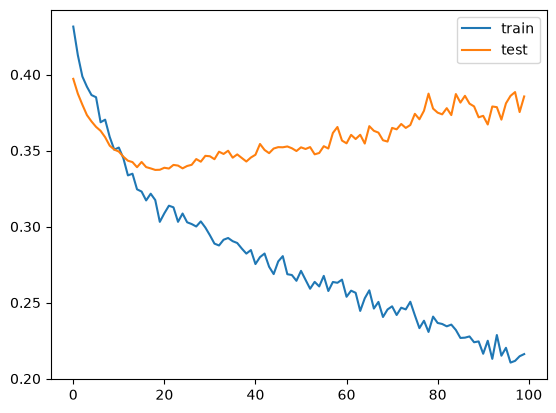

In [64]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

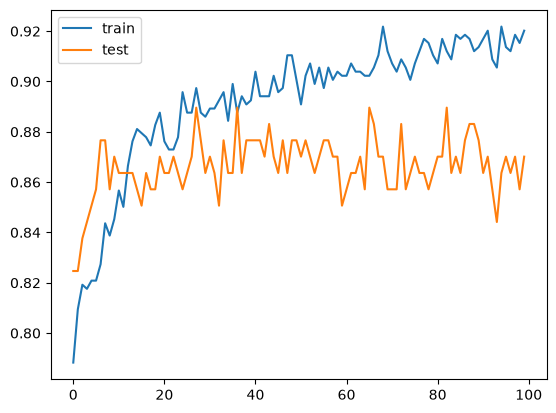

In [65]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show()